In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../outputs/giving_happiness_clean.csv")

In [3]:
df.shape

(10822, 53)

In [4]:
df.head()

,release_2017,family_id_2017,age_2017,sex_2017,life_satisfaction_2017,employment_status_2017,health_status_2017,donor_status_2017,religious_donations_2017,combo_donations_2017,...,wealth_2019,education_2019,marital_status_2019,donor_2017,donor_2019,total_donations_2017,total_donations_2019,giving_rate_2017,giving_rate_2019,donor_inconsistency_2019
0,3.0,5620.0,59.0,2.0,2.0,5.0,4.0,5.0,0.0,0.0,...,1200.0,11.0,4.0,0.0,1.0,0.0,300.0,0.0,2.720348,False
1,3.0,8559.0,57.0,2.0,2.0,1.0,2.0,5.0,0.0,0.0,...,195000.0,12.0,4.0,0.0,0.0,0.0,0.0,0.0,0.000000,False
2,3.0,6510.0,43.0,2.0,3.0,5.0,4.0,5.0,0.0,0.0,...,0.0,12.0,5.0,0.0,0.0,0.0,0.0,0.0,0.000000,False
3,3.0,9172.0,42.0,1.0,3.0,1.0,1.0,5.0,0.0,0.0,...,2000.0,10.0,2.0,0.0,0.0,0.0,0.0,0.0,0.000000,False
4,3.0,7682.0,27.0,2.0,3.0,1.0,3.0,5.0,0.0,0.0,...,14000.0,12.0,4.0,0.0,0.0,0.0,0.0,0.0,0.000000,False


In [5]:
df[
    [
        "life_satisfaction_2017",
        "life_satisfaction_2019",
        "donor_2017",
        "donor_2019",
        "total_donations_2017",
        "total_donations_2019",
        "giving_rate_2017",
        "giving_rate_2019",
        "family_income_2017",
        "family_income_2019",
        "wealth_2017",
        "wealth_2019"
    ]
].describe()

,life_satisfaction_2017,life_satisfaction_2019,donor_2017,donor_2019,total_donations_2017,total_donations_2019,giving_rate_2017,giving_rate_2019,family_income_2017,family_income_2019,wealth_2017,wealth_2019
count,9451.000000,9433.000000,9436.000000,9438.000000,9440.000000,9396.000000,9324.000000,9248.000000,9.607000e+03,9.569000e+03,9.607000e+03,9.569000e+03
mean,2.187070,2.171632,0.450933,0.429540,1142.493008,1087.480204,2.730399,1.664973,7.324559e+04,7.789538e+04,2.408645e+05,2.566594e+05
std,0.844857,0.842389,0.497613,0.495037,4820.218797,3820.222525,99.817371,24.106582,8.526633e+04,8.895981e+04,9.906114e+05,1.181227e+06
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-8.402200e+04,-2.679000e+05,-2.320000e+06,-1.144900e+07
25%,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.700000e+04,2.800000e+04,3.000000e+02,3.000000e+02
50%,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.241200e+04,5.507600e+04,2.830000e+04,3.430000e+04
75%,3.000000,3.000000,1.000000,1.000000,600.000000,525.000000,0.843387,0.743138,9.462000e+04,1.001000e+05,1.640000e+05,1.820000e+05
max,5.000000,5.000000,1.000000,1.000000,274997.000000,136000.000000,9200.000000,1611.111111,2.229087e+06,2.125100e+06,4.574500e+07,5.714500e+07


In [6]:
for year in [2017, 2019]:
    print(f"\n{year}")
    print(df[f"donor_{year}"].value_counts(dropna=False))


2017
donor_2017
0.0    5181
1.0    4255
NaN    1386
Name: count, dtype: int64

2019
donor_2019
0.0    5384
1.0    4054
NaN    1384
Name: count, dtype: int64


In [7]:
for year in [2017, 2019]:
    print(f"\nLife satisfaction {year}")
    print(df[f"life_satisfaction_{year}"].value_counts(dropna=False).sort_index())


Life satisfaction 2017
life_satisfaction_2017
1.0    2029
2.0    4150
3.0    2847
4.0     325
5.0     100
NaN    1371
Name: count, dtype: int64

Life satisfaction 2019
life_satisfaction_2019
1.0    2046
2.0    4242
3.0    2735
4.0     300
5.0     110
NaN    1389
Name: count, dtype: int64


In [8]:
for year in [2017, 2019]:
    print(f"\n{year}")
    print(
        df.groupby(f"donor_{year}")[f"life_satisfaction_{year}"]
        .agg(["count", "mean", "median"])
    )


2017
            count      mean  median
donor_2017                         
0.0          5157  2.277681     2.0
1.0          4249  2.076959     2.0

2019
            count      mean  median
donor_2019                         
0.0          5353  2.245096     2.0
1.0          4046  2.074394     2.0


In [14]:
from scipy.stats import ttest_ind

for year in [2017, 2019]:
    donor_group = df.loc[
        df[f"donor_{year}"] == 1,
        f"life_satisfaction_{year}"
    ].dropna()

    non_donor_group = df.loc[
        df[f"donor_{year}"] == 0,
        f"life_satisfaction_{year}"
    ].dropna()

    t_stat, p_value = ttest_ind(
        donor_group,
        non_donor_group,
        equal_var=False
    )

    print(f"\n{year}")
    print("t-statistic:", round(t_stat, 3))
    print("p-value:", p_value)


2017
t-statistic: -11.709
p-value: 1.9018011608299856e-31

2019
t-statistic: -9.988
p-value: 2.2609153236265355e-23


In [13]:
!pip install scipy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
from scipy.stats import ttest_ind

for year in [2017, 2019]:
    donor_group = df.loc[
        df[f"donor_{year}"] == 1,
        f"life_satisfaction_{year}"
    ].dropna()

    non_donor_group = df.loc[
        df[f"donor_{year}"] == 0,
        f"life_satisfaction_{year}"
    ].dropna()

    t_stat, p_value = ttest_ind(
        donor_group,
        non_donor_group,
        equal_var=False
    )

    print(f"\n{year}")
    print("t-statistic:", round(t_stat, 3))
    print("p-value:", p_value)


2017
t-statistic: -11.709
p-value: 1.9018011608299856e-31

2019
t-statistic: -9.988
p-value: 2.2609153236265355e-23


In [16]:
corr_cols = [
    "life_satisfaction_2017",
    "total_donations_2017",
    "giving_rate_2017",
    "family_income_2017",
    "wealth_2017",
    "life_satisfaction_2019",
    "total_donations_2019",
    "giving_rate_2019",
    "family_income_2019",
    "wealth_2019"
]

df[corr_cols].corr()

,life_satisfaction_2017,total_donations_2017,giving_rate_2017,family_income_2017,wealth_2017,life_satisfaction_2019,total_donations_2019,giving_rate_2019,family_income_2019,wealth_2019
life_satisfaction_2017,1.000000,-0.083840,-0.010565,-0.170726,-0.093558,0.495251,-0.116440,0.000328,-0.180354,-0.083986
total_donations_2017,-0.083840,1.000000,0.170083,0.288390,0.298630,-0.098519,0.771666,0.086894,0.314955,0.311765
giving_rate_2017,-0.010565,0.170083,1.000000,-0.010205,0.010565,-0.002364,0.120674,0.026000,0.007409,0.025928
family_income_2017,-0.170726,0.288390,-0.010205,1.000000,0.414468,-0.156548,0.369672,0.006384,0.805884,0.436470
wealth_2017,-0.093558,0.298630,0.010565,0.414468,1.000000,-0.094802,0.317940,0.027119,0.368838,0.778565
life_satisfaction_2019,0.495251,-0.098519,-0.002364,-0.156548,-0.094802,1.000000,-0.092193,0.005937,-0.165472,-0.084091
total_donations_2019,-0.116440,0.771666,0.120674,0.369672,0.317940,-0.092193,1.000000,0.118713,0.369497,0.326621
giving_rate_2019,0.000328,0.086894,0.026000,0.006384,0.027119,0.005937,0.118713,1.000000,-0.010045,0.064628
family_income_2019,-0.180354,0.314955,0.007409,0.805884,0.368838,-0.165472,0.369497,-0.010045,1.000000,0.417695
wealth_2019,-0.083986,0.311765,0.025928,0.436470,0.778565,-0.084091,0.326621,0.064628,0.417695,1.000000


In [17]:
df["change_life_satisfaction"] = (
    df["life_satisfaction_2019"] -
    df["life_satisfaction_2017"]
)

df["change_donations"] = (
    df["total_donations_2019"] -
    df["total_donations_2017"]
)

df["change_income"] = (
    df["family_income_2019"] -
    df["family_income_2017"]
)

df["change_wealth"] = (
    df["wealth_2019"] -
    df["wealth_2017"]
)

In [18]:
df[
    [
        "change_life_satisfaction",
        "change_donations",
        "change_income",
        "change_wealth"
    ]
].corr()

,change_life_satisfaction,change_donations,change_income,change_wealth
change_life_satisfaction,1.000000,0.000457,-0.003717,-0.008489
change_donations,0.000457,1.000000,0.056863,0.059951
change_income,-0.003717,0.056863,1.000000,0.076374
change_wealth,-0.008489,0.059951,0.076374,1.000000


In [19]:
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [20]:
!pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.3 MB 6.1 MB/s eta 0:00:02
   ---------- ----------------------------- 2.4/9.3 MB 5.8 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.3 MB 5.9 MB/s eta 0:00:01
   -------------------- ------------------- 4.7/9.3 MB 5.9 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.3 MB 5.8 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.3 MB 5.3 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.3 MB 5.4 MB/s eta 0:00:01
   -------------------------------------- - 8.9/9.3 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 5.1 MB/s  0:00:01
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------ --------------------------- 0.8/2.5 MB 4.8 MB/s eta 0:00:01
   --------------------------------- ------ 2.1/2.5 MB 4.9 MB/s eta 0:00:01
   --------------------------

ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: 'C:\\Python312\\share\\man\\man1\\ttx.1'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [22]:
!pip install matplotlib

  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl (234 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)

   ------------- -------------------------- 1/3 [contourpy]
   -------------------------- ------------- 2/3 [matplotlib]
   -------------------------- ------------- 2/3 [matplotlib]
   -------------------------- ------------- 2/3 [matplotlib]
   -------------------------- ------------- 2/3 [matplotlib]
   -------------------------- ------------- 2/3 [matplotlib]
   -------------------------- ------------- 2/3 [matplotlib]
   -------------------------- ------------- 2/3 [matplotlib]
   -------------------------- ------------- 2/3 [matplotlib]
   -------------------------- ------------- 2/3 [matp


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import matplotlib.pyplot as plt

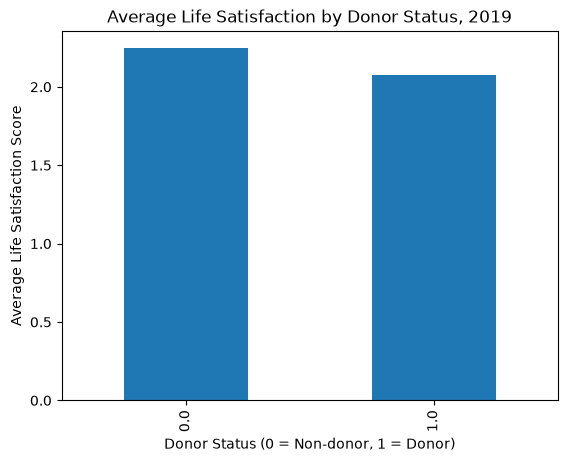

In [24]:
means_2019 = df.groupby("donor_2019")["life_satisfaction_2019"].mean()

means_2019.plot(kind="bar")
plt.title("Average Life Satisfaction by Donor Status, 2019")
plt.xlabel("Donor Status (0 = Non-donor, 1 = Donor)")
plt.ylabel("Average Life Satisfaction Score")
plt.show()

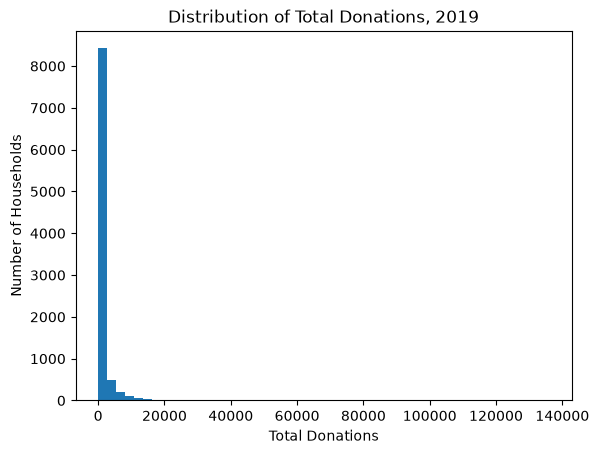

In [25]:
df["total_donations_2019"].plot(kind="hist", bins=50)

plt.title("Distribution of Total Donations, 2019")
plt.xlabel("Total Donations")
plt.ylabel("Number of Households")
plt.show()

In [26]:
!pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 2.8 MB/s eta 0:00:04
   ------ --------------------------------- 1.8/11.3 MB 4.4 MB/s eta 0:00:03
   ---------- ----------------------------- 2.9/11.3 MB 4.8 MB/s eta 0:00:02
   -------------- ------------------------- 4.2/11.3 MB 5.1 MB/s eta 0:00:02
   ------------------- -------------------- 5.5/11.3 MB 5.3 MB/s eta 0:00:02
   ----------------------- ---------------- 6.6/11.3 MB 5.4 MB/s eta 0:00:01
   --------------------------- ------------ 7.9/11.3 MB 5.5 MB/s eta 0:00:01
   -------------------------------- ------- 9.2/11.3 MB 5.5 MB/s eta 0:00:01
   ------------------------------------ --- 10.2/11.3 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 5.2 MB/s  0:00:02

   ------ --------------------------------- 1/6 [patsy]
   ------ ----------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import statsmodels.formula.api as smf

model_2019 = smf.ols(
    "life_satisfaction_2019 ~ donor_2019 + family_income_2019 + wealth_2019 + age_2019 + education_2019 + health_status_2019",
    data=df
).fit()

print(model_2019.summary())

                              OLS Regression Results                              
Dep. Variable:     life_satisfaction_2019   R-squared:                       0.110
Model:                                OLS   Adj. R-squared:                  0.110
Method:                     Least Squares   F-statistic:                     191.9
Date:                    Wed, 16 Sep 2026   Prob (F-statistic):          2.38e-231
Time:                            20:51:44   Log-Likelihood:                -11030.
No. Observations:                    9297   AIC:                         2.207e+04
Df Residuals:                        9290   BIC:                         2.212e+04
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [28]:
model_2017 = smf.ols(
    "life_satisfaction_2017 ~ donor_2017 + family_income_2017 + wealth_2017 + age_2017 + education_2017 + health_status_2017",
    data=df
).fit()

print(model_2017.summary())

                              OLS Regression Results                              
Dep. Variable:     life_satisfaction_2017   R-squared:                       0.110
Model:                                OLS   Adj. R-squared:                  0.109
Method:                     Least Squares   F-statistic:                     190.1
Date:                    Wed, 16 Sep 2026   Prob (F-statistic):          3.20e-229
Time:                            20:58:47   Log-Likelihood:                -11060.
No. Observations:                    9273   AIC:                         2.213e+04
Df Residuals:                        9266   BIC:                         2.218e+04
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [29]:
summary_results = pd.DataFrame({
    "year": [2017, 2019],
    "donor_coefficient": [
        model_2017.params["donor_2017"],
        model_2019.params["donor_2019"]
    ],
    "donor_p_value": [
        model_2017.pvalues["donor_2017"],
        model_2019.pvalues["donor_2019"]
    ],
    "r_squared": [
        model_2017.rsquared,
        model_2019.rsquared
    ]
})

summary_results

,year,donor_coefficient,donor_p_value,r_squared
0,2017,-0.076490,0.000060,0.109615
1,2019,-0.048286,0.010889,0.110291


In [31]:
summary_results.to_csv(
    "../outputs/exploratory_summary.csv",
    index=False
)